# Custom Data Processors

One of the foundational components of this framework is the `Data Processor` node. These nodes are responsible for transforming individual examples of data, making them essential for feature engineering and enrichment tasks.

In this tutorial, we’ll guide you through the process of implementing a custom data processor that can be integrated seamlessly into a `DataFlow`. By the end, you will understand how to:

1. Define your own processor class.
2. Integrate your custom processor into a data flow graph.
3. Execute a complete workflow to see your processor in action.

In [1]:
%config InlineBackend.figure_format = 'svg'

## Imports

Before diving into implementing a custom data processor, let’s start by importing the necessary components:

In [2]:
import datasets
from hyped import DataFlow, plot_data_flow
from hyped.core import BaseDataProcessor, BaseDataProcessorConfig, RunContext, ValidationSession, process_mode
from hyped.typing import Int, Float, Mapping, FeatureValidator, FeatureResolver, ExcludeFieldIf, Annotated

## Creating a Data Flow

Next, we'll create a simple dataset and a data flow instance from it:

In [3]:
ds = datasets.Dataset.from_dict({"x": [0, 1, 2, 3, 4]})
flow = DataFlow(ds.features)

## Implementing a Custom Data Processor

In this section, we'll demonstrate how to create a custom data processor by building on the core components of `hyped`. A custom data processor consists of two primary parts:

1. A configuration class that defines the processor's parameters.
2. The processor class itself, which implements the transformation logic.

Let’s start with a simple example.

### Step 1: Define the Processor Configuration

The configuration class specifies the parameters your custom processor will use. It inherits from `BaseDataProcessorConfig` and allows you to define any settings or hyperparameters required for your transformation.

In [4]:
class CustomProcessorConfig(BaseDataProcessorConfig):
    val: int

In this example, `val` is an integer parameter that controls the behavior of the processor. You can add more fields to this class as needed to support additional configuration options.

### Step 2: Implement the Processor Logic

The processor class contains the actual transformation logic. It inherits from `BaseDataProcessor`, which provides a structured interface for defining custom processors. Specifically, you need to implement the process method, which takes in a `RunContext` object and the input data to be processed. In this case, it's an integer (`Int`), as specified by the type hint.

In [5]:
class CustomProcessor(BaseDataProcessor[CustomProcessorConfig]):
    def process(self, ctx: RunContext, x: Int) -> Int:
        return x * self.config.val

**Importance of Type Annotations**

One of the key features of the `hyped` is its ability to validate input and infer output types from the type annotations. Make sure to always use the types provided by `hyped.typing` to annotate the `process` function.

During the construction of the data flow, these type annotations are used to infer and propagate feature types across the pipeline. This ensures that the data flow is consistent and that downstream processors receive the correct types.


## Using the Custom Data Processor

Now that we've implemented a custom data processor, let’s see how to integrate it into a DataFlow pipeline. This section will walk you through the steps using the custom processor and executing the pipeline to transform your dataset.

To use the custom processor in your data flow, you instantiate it with its configuration parameters and call it on a feature from the flow’s source.

In [6]:
out = CustomProcessor(val=4).call(x=flow.source["x"])

- `CustomProcessor(val=4)`: Creates an instance of the processor with `val=4` as its configuration parameter.
- `.call(x=flow.source["x"])`: Specifies that the processor will operate on the feature `"x"` from the data flow's source. The output is captured in the variable `out`.

Once you’ve defined your data flow, you can visualize its structure to verify that the custom processor is added to the underlying processing graph.

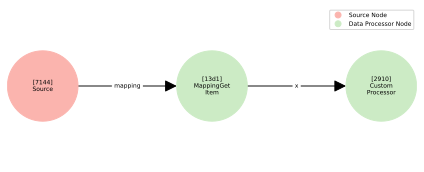

In [7]:
plot_data_flow(flow);

To process a dataset using the data flow, call the `apply` method. This method applies the transformations defined in the data flow to the dataset and collects the specified outputs.

In [8]:
out_ds = flow.apply(ds, collect={"out": out})

Map:   0%|          | 0/5 [00:00<?, ? examples/s]

`collect={"out": out}` specifies that the output of the processor should be collected in the resulting dataset under the key `"out"`.

In [9]:
out_ds.to_dict()

{'out': [0, 4, 8, 12, 16]}

## Advanced Usage

The DataFlow framework provides advanced features that enable greater flexibility and efficiency in data processing. In this section, we’ll explore some of these features, starting with the `process_mode` decorator.


## Returning Multiple Outputs

In some scenarios, a processor needs to generate multiple outputs instead of a single value. The framework supports this by allowing the processor to return a custom mapping type. Each field in the mapping represents a distinct output that can be used downstream in the data flow.

Here’s how you can define and use a processor that generates multiple outputs:

In [10]:
class CustomOutput(Mapping):
    fieldA: Int
    fieldB: Int

class CustomProcessorConfigV2(BaseDataProcessorConfig):
    val: int

class CustomProcessorV2(BaseDataProcessor[CustomProcessorConfigV2]):

    def process(self, ctx: RunContext, x: Int) -> CustomOutput:
        return {
            "fieldA": x * self.config.val,
            "fieldB": x * self.config.val ** 2
        }


In this example, the processor returns a `CustomOutput` type, which is a mpping where each key-value pair corresponds to a specific output field. The `process` method generates a dictionary matching the structure defined by `CustomOutput`.

Once the processor is defined, it can be seamlessly integrated into the data flow, and its outputs can be collected as part of the dataset:

In [11]:
# Define the output of the processor
out = CustomProcessorV2(val=2).call(x=flow.source["x"])

# Apply the data flow to the dataset, collecting the outputs
out_ds = flow.apply(ds, collect=out)

# Convert the resulting dataset to a dictionary for inspection
out_ds.to_dict()

Map:   0%|          | 0/5 [00:00<?, ? examples/s]

{'fieldA': [0, 2, 4, 6, 8], 'fieldB': [0, 4, 8, 12, 16]}

Note how in this case we can pass the output directly as the collect feature. The collect feature requires a mapping data type which is satisfied by the output of the processor.

## Conditional Output Fields

In some scenarios, the fields included in the processor's output need to be determined dynamically based on configuration values. The framework allows you to define conditional outputs by combining a custom mapping type with dynamic field exclusions.

Here’s how you can define a processor that conditionally includes or excludes certain fields in its output:

In [12]:
class CustomProcessorConfigV3(BaseDataProcessorConfig):
    val: int
    returns_fieldB: bool

class CustomOutput(Mapping):
    fieldA: Int
    fieldB: Annotated[Int, ExcludeFieldIf(lambda c, i, _: not c.returns_fieldB)]

class CustomProcessorV3(BaseDataProcessor[CustomProcessorConfigV3]):

    def process(self, ctx: RunContext, x: Int) -> CustomOutput:
        if self.config.returns_fieldB:
            # return both fieldA and fieldB
            return {
                "fieldA": x * self.config.val,
                "fieldB": x * self.config.val ** 2
            }
        else:
            # return only fieldA
            return {"fieldA": x * self.config.val}


Here, `CustomOutput` is a mapping that conditionally includes `fieldB`. The `ExcludeFieldIf` decorator ensures that `fieldB` is excluded if the condition `not c.returns_fieldB` evaluates to `True`. The `process` method dynamically adjusts the returned mapping based on the `returns_fieldB` flag in the configuration.

You can easily integrate the processor into a data flow and collect its outputs dynamically:

In [13]:
# Define the output of the processor
out_without_fieldB = CustomProcessorV3(val=2, returns_fieldB=False).call(x=flow.source["x"])
out_with_fieldB = CustomProcessorV3(val=2, returns_fieldB=True).call(x=flow.source["x"])

# Apply the data flow to the dataset, collecting the outputs
out_ds = flow.apply(
    ds,
    collect={
        "outA": out_without_fieldB,
        "outB": out_with_fieldB,
    }
)

# Convert the resulting dataset to a dictionary for inspection
print("returns_fieldB=False:", out_ds.to_dict()["outA"])
print("returns_fieldB=True: ", out_ds.to_dict()["outB"])

Map:   0%|          | 0/5 [00:00<?, ? examples/s]

returns_fieldB=False: [{'fieldA': 0}, {'fieldA': 2}, {'fieldA': 4}, {'fieldA': 6}, {'fieldA': 8}]
returns_fieldB=True:  [{'fieldA': 0, 'fieldB': 0}, {'fieldA': 2, 'fieldB': 4}, {'fieldA': 4, 'fieldB': 8}, {'fieldA': 6, 'fieldB': 12}, {'fieldA': 8, 'fieldB': 16}]


Note how the output dataset only includes `fieldA` in the first case where the processor was initialized with `returns_fieldB=False`, while it includes both fields in the other case.

### Using the `process_mode` Decorator

By default, the `process` method in a custom processor operates on individual examples. However, there are cases where processing multiple examples at once (in batches) can significantly improve performance, especially when working with large datasets or computationally intensive transformations.

The `process_mode` decorator allows you to specify whether the process method operates in a batched or single-example mode.

Here’s how to define a processor that operates in batched mode:

In [14]:
class CustomProcessorConfigV4(BaseDataProcessorConfig):
    val: int

class CustomProcessorV4(BaseDataProcessor[CustomProcessorConfigV4]):

    @process_mode(batched=True)
    def process(self, ctx: RunContext, x: Int) -> Int:
        return [v * self.config.val for v in x]

The `process_mode(batched=True)` decorator indicates that the process method will receive a batch of inputs (e.g., a list of integers) instead of a single example. The method must return a batch of outputs of the same length as the input batch.

Note that the new batched `CustomProcessorV2` achieves the same result as the basic implementation in `CustomProcessor` but processes inputs in batches:

In [15]:
# Use the batched CustomProcessorV2
out = CustomProcessorV4(val=4).call(x=flow.source["x"])

# Apply the data flow to the dataset
out_ds = flow.apply(ds, collect={"out": out})

print(out_ds.to_dict())

Map:   0%|          | 0/5 [00:00<?, ? examples/s]

{'out': [0, 4, 8, 12, 16]}


### Using Type Variables

In more advanced use cases, you may want to define processors that are type-agnostic or can work with different types of data. The `TypeVar` from Python's `typing` module allows you to define such flexible processor signatures by introducing type parameters. This allows your processors to handle multiple data types while ensuring type safety.

In [16]:
from typing import TypeVar

class CustomProcessorConfigV5(BaseDataProcessorConfig):
    ...

T = TypeVar("T", Int, Float)

class CustomProcessorV5(BaseDataProcessor[CustomProcessorConfigV5]):
    def process(self, ctx: RunContext, x: T, y: T) -> T:
        return x + y

When using `TypeVar` in a processor’s signature, the output type is dynamically inferred from the input arguments. However, it’s important to understand that `TypeVar` doesn't enforce exact matching between the input types; instead, it allows types that are castable to each other.

This behavior makes the processor more flexible, as it can work with different but compatible types, such as an `Int` and a `Float`, and automatically adjust the result to a compatible output type.

In [17]:
from hyped.typing import cast

int_feature = flow.source["x"]
float_feature = cast(Float, flow.source["x"])

int_out = CustomProcessorV5().call(x=int_feature, y=int_feature)
float_out = CustomProcessorV5().call(x=float_feature, y=float_feature)
mixed_out = CustomProcessorV5().call(x=int_feature, y=float_feature)

print("x: Int, y: Int ->    ", int_out.dtype)
print("x: Float, y: Float ->", float_out.dtype)
print("x: Int, y: Float ->  ", mixed_out.dtype)

ImportError: cannot import name 'cast' from 'hyped.typing' (/Users/ndoll/dev/open-hyped/hyped/src/hyped/typing.py)

### Custom Feature Validation

The `FeatureValidator` allows you to implement custom feature validation based on processor configuration. This is particularly useful when your processor needs to enforce specific constraints on the input features, depending on how it has been configured.

In [17]:
class CustomProcessorConfigV6(BaseDataProcessorConfig):
    expects_float: bool

def custom_feature_validation(
    feature: Int | Float,
    config: CustomProcessorConfigV6,
    session: ValidationSession
) -> Int | Float:
    if isinstance(feature, Int) and config.expects_float:
        raise TypeError("Expected Float")
    return feature

class CustomProcessorV6(BaseDataProcessor[CustomProcessorConfigV6]):

    def process(
        self,
        ctx: RunContext,
        x: Annotated[Int | Float, FeatureValidator(custom_feature_validation)]
    ) -> Int:
        return int(x)

In this example, we combine configuration-specific logic with feature validation to ensure that the inputs to our processor match the expected types. Let's break down the key components:

1. **Configuration-Specific Logic**: The `CustomProcessorConfigV3` class has a configuration parameter `expects_float`, which controls whether the processor expects its input to be a `Float`. This configuration is passed to the processor and determines the validation rules for the features.

2. **Feature Validation**: The `custom_feature_validation` function is a custom validator that checks the type of the input feature. If the feature is an `Int` but the configuration expects a `Float`, the function raises a `TypeError`. This ensures that the input meets the necessary criteria before the processor does any further work.

3. **Using the `FeatureValidator`**: In the `process` method of the `processor`, we annotate the input feature `x` with `FeatureValidator(custom_feature_validation)`. This tells the framework to apply the `custom_feature_validation` function to `x` before it proceeds with processing. The validator checks whether the feature matches the expected type based on the configuration.

In [18]:
# expects float but receives int
out = CustomProcessorV6(expects_float=True).call(x=flow.source["x"])

TypeError: Expected Float

### Feature Validation Session

In more complex scenarios, you may need to perform validation that goes beyond simple type checking. The **FeatureValidator** provides a powerful mechanism for dynamic validation, allowing you to store and manage additional context across multiple validation functions within the same **session**.

What makes the **FeatureValidator** system particularly powerful is that the `session` is not limited to validating a single feature. Instead, it can be used to manage the validation context across various features, even across multiple validation functions. Information stored in the context can then be accessed and referenced throughout the entire validation process, allowing for more sophisticated validation logic that depends on the accumulated context.

The **lifetime of the validation session** is tied to the validation of the function signature. Specifically, the session remains active from the moment the input arguments are validated until the output features are constructed. This means the session spans the entire duration of the validation process, ensuring that the context persists across the validation of both inputs and outputs.

The following example makes use of the validation `session` to ensure that two input features are of the exact same data type. 

In [18]:
class CustomProcessorConfigV7(BaseDataProcessorConfig):
    outputs_float: bool

def match_feature_validator(
    feature: Int | Float,
    config: CustomProcessorConfigV7,
    session: ValidationSession
):
    # capture data type of the feature in the validation session
    if session.get_context("feature_dtype") is None:
        session.set_context("feature_dtype", feature.dtype)

    # compare the dtype of the feature with the captured dtype
    if feature.dtype != session.get_context("feature_dtype"):
        raise TypeError("DType Mismatch")

class CustomProcessorV7(BaseDataProcessor[CustomProcessorConfigV7]):

    def process(
        self,
        ctx: RunContext,
        x: Annotated[Int | Float, FeatureValidator(match_feature_validator)],
        y: Annotated[Int | Float, FeatureValidator(match_feature_validator)]
    ) -> Int:
        return int(x + y)

In this example, we make use of the validation session to store the data type of the input feature as context information.

1. **Validation Context**: In the `match_feature_validator` function, the data type (`dtype`) of the feature is stored in the session using `session.set_context`. This allows us to track the data type of the feature across multiple validation calls and enforce consistency. If the data type of the next feature doesn't match the first one, we raise a `TypeError`.
2. **Multiple Inputs**: The process method in `CustomProcessorV4` takes two inputs, `x` and `y`, both of which are validated using the `match_feature_validator`. Both features are compared to ensure they share the same data type, ensuring the processor operates on consistent inputs.

### Custom Feature Resolver

The `FeatureResolver` is a powerful tool that allows you to implement custom logic for determining the output feature type of a `processor`. This can be particularly useful when you need to dynamically infer the type of the output based on certain conditions, such as the configuration or the types of input features.

By using the feature resolver, you can define custom logic that adapts the data processing pipeline to different requirements, making it more flexible and dynamic.

In [19]:
class CustomProcessorConfigV8(BaseDataProcessorConfig):
    outputs_float: bool

def custom_feature_resolver(
    config: None | CustomProcessorConfigV8,
    inputs: dict[str, Int | Float],
    session: ValidationSession
) -> type[Int] | type[Float]:
    return Float if config.outputs_float else Int

class CustomProcessorV8(BaseDataProcessor[CustomProcessorConfigV8]):

    def process(
        self,
        ctx: RunContext,
        x: Int,
    ) -> Annotated[Int | Float, FeatureResolver(custom_feature_resolver)]:
        ...

In this example, the `custom_feature_resolver` function is responsible for inferring the output feature type. It takes in the `config`, a dictionary of `inputs`, and a `session` as arguments. The `process` method in the `CustomProcessorV5` class uses the `FeatureResolver` decorator to apply the `custom_feature_resolver` function to determine the output type of the processor.

We can check the behavior by calling the processor with different configurations:

In [20]:
int_out = CustomProcessorV8(outputs_float=False).call(x=flow.source["x"])
float_out = CustomProcessorV8(outputs_float=True).call(x=flow.source["x"])

print("Output dtyle (outputs_float=False):", int_out.dtype)
print("Output dtyle (outputs_float=True): ", float_out.dtype)

Output dtyle (outputs_float=False): Int64
Output dtyle (outputs_float=True):  Double
